# What makes a simulation of `model10` random?

`plots/model10/inference.npz` stores 10 trained seeds x 30 rollouts, and every rollout differs.
This notebook asks *why* — which knobs actually inject randomness once training is over and we
are only simulating.

Reading the code (`envs/xro_env.py`, `utils/evaluation.py`) there are exactly **two** stochastic
streams inside a rollout, plus one source that lives outside it:

| # | source | where it enters | stream |
|---|--------|-----------------|--------|
| 1 | **start state** | `reset()` draws a random year (1979-2022) and month, then loads that observed state | `env.rng_init` |
| 2 | **physics noise** | every `step()` passes `rng_physics` to `xro_step` -> `XRO.simulate` | `env.rng_physics` |
| 3 | **trained weights** | which of the 10 `model10_seed*.zip` policies is loaded | not a stream |

Note what is *absent*: `simulate_trajectory` calls `agent.predict(obs, deterministic=True)`, so
**action sampling contributes nothing at inference**. It is a training-time axis only.

The catch: `reset(seed=s)` does `SeedSequence(s).spawn(2)` and derives *both* streams from the one
seed. That is deliberate — it makes agent/baseline pairs comparable — but it means the saved
`inference.npz` cannot separate axis 1 from axis 2. To decompose them we have to re-simulate with
the two generators set independently, which is what this notebook does.

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# This notebook LOADS MODELS (unlike analysis.ipynb, which only reads npz files), and
# model_io / EnvConfig resolve "models/..." and the data path relative to the CWD — so
# run from the repo root. The guard makes re-running the cell a no-op.
REPO = Path("..").resolve() if Path("../models").exists() else Path(".").resolve()
sys.path.insert(0, str(REPO))
os.chdir(REPO)

from utils.model_io import load_environment
from utils.evaluation import simulate_trajectory
from utils.enso_classifier import _find_continuous_runs
from utils import suppress_warnings
from config import EnvConfig

suppress_warnings()
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

NAME   = "model10"
NI, NP = 5, 5                 # init seeds x physics seeds in the factorial grid
T_LIST = [120, 360, 1200]     # horizons (months) — 10, 30, 100 years
T_MAIN = 1200                 # horizon used for the headline numbers (matches inference.npz)
N_MODELS = 10
MASTER = 20240728

rng = np.random.default_rng(MASTER)
INIT_SEEDS = [int(x) for x in rng.integers(0, 2**31, NI)]
PHYS_SEEDS = [int(x) for x in rng.integers(0, 2**31, NP)]

model, env, var_names = load_environment(f"{NAME}_seed0", EnvConfig())
print("cwd:", Path.cwd())
print("init seeds:", INIT_SEEDS)
print("phys seeds:", PHYS_SEEDS)

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
cwd: /Users/ayman/research/enso-rl
init seeds: [904554661, 1035852979, 370491302, 86689062, 1722068386]
phys seeds: [1160568988, 1505183543, 1332051398, 130116083, 491087057]


## Rollout helper — the two streams, set independently

`env.reset(seed=s)` re-derives both generators from `s`. Setting `rng_init` and `rng_physics`
by hand and then resetting with `seed=None` leaves them untouched, so the axes stay orthogonal
and a factorial design becomes possible.

In [2]:
def rollout(env, agent, T, s_init, s_phys):
    """One rollout with the two environment RNG streams set INDEPENDENTLY.

    reset(seed=s) spawns both streams from one seed (XROMultiYearEnv.reset) — convenient for
    paired agent/baseline comparisons, but it welds the two axes together. Assigning the
    generators directly and passing seed=None keeps reset() from re-deriving them.
    """
    env.rng_init    = np.random.default_rng(s_init)
    env.rng_physics = np.random.default_rng(s_phys)
    return simulate_trajectory(env, agent=agent, num_months=T, seed=None)


MET = ["MYE occupancy", "MY events / century", "peak |Nino3.4|", "var(Nino3.4)"]

def metrics(sim):
    """Four summary statistics of one rollout, scaled so horizons are comparable."""
    cls = np.asarray(sim["classified_event_array"]); T = len(cls)
    mye = np.isin(cls, ["Multi-year El Nino", "Multi-year La Nina"])
    n_ev = sum(len(_find_continuous_runs((cls == lab).astype(int)))
               for lab in ("Multi-year El Nino", "Multi-year La Nina"))
    return np.array([mye.mean(), n_ev * 1200.0 / T,
                     np.abs(sim["enso_traj"]).max(), np.var(sim["enso_traj"])])

## 0. Is a rollout reproducible at all?

Before decomposing variance, confirm the run is a deterministic function of the two seeds —
i.e. there is no *third*, unseeded source of randomness hiding in the loop.

In [3]:
a = rollout(env, model, 240, INIT_SEEDS[0], PHYS_SEEDS[0])
b = rollout(env, model, 240, INIT_SEEDS[0], PHYS_SEEDS[0])
c = rollout(env, model, 240, INIT_SEEDS[0], PHYS_SEEDS[1])   # physics only
d = rollout(env, model, 240, INIT_SEEDS[1], PHYS_SEEDS[0])   # start state only

obs, _ = env.reset(seed=1)
p1, _ = model.predict(obs, deterministic=True)
p2, _ = model.predict(obs, deterministic=True)

print("same (init, phys) twice -> identical trajectory :", np.array_equal(a["enso_traj"], b["enso_traj"]))
print("policy is deterministic at inference            :", np.array_equal(p1, p2))
print("changing physics seed alone changes the run     :", not np.array_equal(a["enso_traj"], c["enso_traj"]))
print("changing init seed alone changes the run        :", not np.array_equal(a["enso_traj"], d["enso_traj"]))
print("start state unchanged when only physics varies  :", np.allclose(a["states_traj"][0], c["states_traj"][0]))
print("start month:", a["month_offset"], "(init seed A) vs", d["month_offset"], "(init seed B)")

same (init, phys) twice -> identical trajectory : True
policy is deterministic at inference            : True
changing physics seed alone changes the run     : True
changing init seed alone changes the run        : True
start state unchanged when only physics varies  : True
start month: 11 (init seed A) vs 11 (init seed B)


## 1. Factorial grid: start state x physics noise

A balanced `NI x NP` grid of (init seed, physics seed) pairs, run for the agent and for the
zero-action baseline, at three horizons. Because the design is balanced we can split the spread
into a start-state effect, a physics effect, and their interaction.

Cost is roughly `2 * NI * NP * sum(T_LIST)` months of simulation — about 7 minutes at the
defaults. Shrink `NI`, `NP` or `T_LIST` for a quick pass.

In [4]:
t0 = time.time()
GRID = {}
for T in T_LIST:
    A = np.zeros((NI, NP, len(MET))); B = np.zeros((NI, NP, len(MET)))
    for i, si in enumerate(INIT_SEEDS):
        for p, sp in enumerate(PHYS_SEEDS):
            A[i, p] = metrics(rollout(env, model, T, si, sp))
            B[i, p] = metrics(rollout(env, None,  T, si, sp))
    GRID[T] = (A, B)
    print(f"T = {T:>5} months done  ({time.time() - t0:.0f}s elapsed)")

T =   120 months done  (34s elapsed)
T =   360 months done  (136s elapsed)
T =  1200 months done  (506s elapsed)


### Variance decomposition

For a balanced two-way layout $X_{ip} = \mu + a_i + b_p + e_{ip}$, the row means carry the
residual as well as the row effect ($\operatorname{var}(\bar X_{i\cdot}) = \sigma^2_{\text{init}} +
\sigma^2_e / N_P$), so the residual is subtracted off before reporting each axis — the same
noise-floor correction used for the training-side seed analysis.

In [5]:
def decompose(X):
    """Balanced two-way decomposition of X[i, p]; returns noise-corrected SDs.

    Row/column means contain the residual too, so var(row mean) = var_init + var_resid/NP.
    Subtracting that floor keeps an axis from inheriting spread it did not cause.
    """
    mu = X.mean()
    a  = X.mean(axis=1) - mu          # start-state effect
    b  = X.mean(axis=0) - mu          # physics effect
    E  = X - mu - a[:, None] - b[None, :]
    ni, npp = X.shape
    ms_e = (E ** 2).sum() / max((ni - 1) * (npp - 1), 1)
    sd_i = np.sqrt(max(a.var(ddof=1) - ms_e / npp, 0.0))
    sd_p = np.sqrt(max(b.var(ddof=1) - ms_e / ni,  0.0))
    return dict(mean=mu, sd_total=X.std(ddof=1), sd_init=sd_i,
                sd_phys=sd_p, sd_inter=np.sqrt(ms_e))


for T in T_LIST:
    A, B = GRID[T]
    print(f"\n=== T = {T} months ({T // 12} yr) — AGENT " + "=" * 34)
    print(f"{'metric':<22}{'mean':>10}{'SD total':>10}{'SD init':>10}{'SD phys':>10}{'SD inter':>10}")
    for m, name in enumerate(MET):
        d = decompose(A[:, :, m])
        print(f"{name:<22}{d['mean']:>10.3f}{d['sd_total']:>10.3f}"
              f"{d['sd_init']:>10.3f}{d['sd_phys']:>10.3f}{d['sd_inter']:>10.3f}")


=== T = 120 months (10 yr) — AGENT ==================================
metric                      mean  SD total   SD init   SD phys  SD inter
MYE occupancy              0.725     0.070     0.005     0.000     0.071
MY events / century       39.273     3.483     0.000     0.000     3.711
peak |Nino3.4|             2.638     0.259     0.000     0.000     0.272
var(Nino3.4)               1.667     0.367     0.191     0.000     0.339

=== T = 360 months (30 yr) — AGENT ==================================
metric                      mean  SD total   SD init   SD phys  SD inter
MYE occupancy              0.791     0.029     0.000     0.009     0.029
MY events / century       42.283     1.523     0.526     0.847     1.221
peak |Nino3.4|             2.752     0.042     0.000     0.000     0.042
var(Nino3.4)               1.924     0.196     0.038     0.000     0.209

=== T = 1200 months (100 yr) — AGENT ==================================
metric                      mean  SD total   SD init   

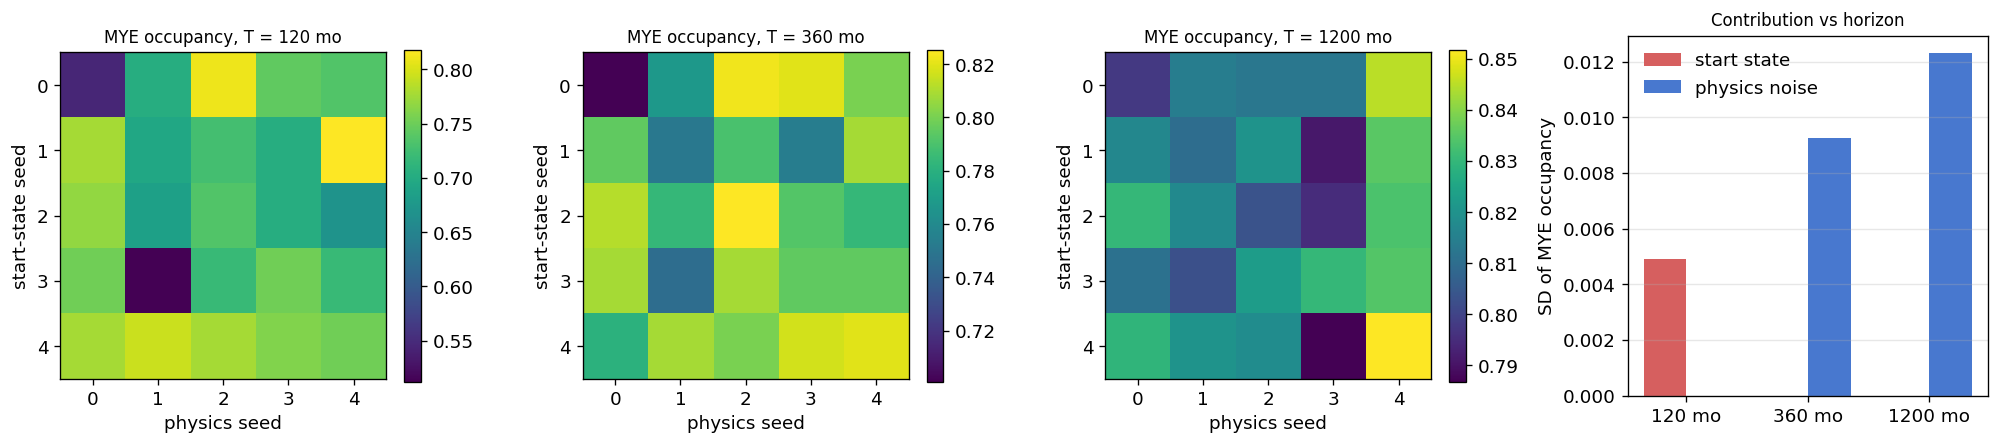

In [6]:
# Heatmap of the grid + how each axis's contribution scales with horizon
fig, axes = plt.subplots(1, len(T_LIST) + 1, figsize=(4.2 * (len(T_LIST) + 1), 3.8))
for ax, T in zip(axes, T_LIST):
    A, _ = GRID[T]
    im = ax.imshow(A[:, :, 0], cmap="viridis")
    ax.set_title(f"MYE occupancy, T = {T} mo", fontsize=10)
    ax.set_xlabel("physics seed"); ax.set_ylabel("start-state seed")
    ax.set_xticks(range(NP)); ax.set_yticks(range(NI))
    fig.colorbar(im, ax=ax, fraction=0.046)

ax = axes[-1]
w = 0.35
for k, (key, col, lab) in enumerate([("sd_init", "#D65F5F", "start state"),
                                     ("sd_phys", "#4878CF", "physics noise")]):
    vals = [decompose(GRID[T][0][:, :, 0])[key] for T in T_LIST]
    ax.bar(np.arange(len(T_LIST)) + (k - 0.5) * w, vals, w, color=col, label=lab)
ax.set_xticks(range(len(T_LIST))); ax.set_xticklabels([f"{T} mo" for T in T_LIST])
ax.set_ylabel("SD of MYE occupancy"); ax.set_title("Contribution vs horizon", fontsize=10)
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

## 2. The third source: which trained policy

The start state and the physics noise are properties of the *simulation*. The remaining source
is the policy itself — the ten `model10_seed*` files are ten different controllers. Scoring all
ten on the **same** (init, phys) draws isolates the weights: evaluation-draw difficulty is a
shared main effect and cancels in the across-model comparison.

The zero-action baseline does not depend on the policy, so it is not re-run here.

In [7]:
pairs = list(zip(INIT_SEEDS, PHYS_SEEDS))     # NI paired draws, held fixed across models
MODEL_AX = np.zeros((N_MODELS, len(pairs), len(MET)))
t0 = time.time()
for m in range(N_MODELS):
    mo, en, _ = load_environment(f"{NAME}_seed{m}", EnvConfig())
    for j, (si, sp) in enumerate(pairs):
        MODEL_AX[m, j] = metrics(rollout(en, mo, T_MAIN, si, sp))
    print(f"seed {m} done ({time.time() - t0:.0f}s)")

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
seed 0 done (35s)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
seed 1 done (70s)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
seed 2 done (104s)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
seed 3 done (137s)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
seed 4 done (168s)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
seed 5 done (198s)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
seed 6 done (229s)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
seed 7 done (260s)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
seed 8 done (291s)
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
seed 9 done (322s)


In [8]:
# Across-model SD, with the same paired noise-floor correction (draws are the block factor)
print(f"{'metric':<22}{'mean':>10}{'SD model':>10}{'floor':>10}{'SD/floor':>10}")
model_sd = {}
for m, name in enumerate(MET):
    X = MODEL_AX[:, :, m]                       # [model, draw]
    d = decompose(X)                            # rows = models, cols = draws
    floor = d["sd_inter"] / np.sqrt(X.shape[1])
    model_sd[name] = d["sd_init"]
    print(f"{name:<22}{X.mean():>10.3f}{d['sd_init']:>10.3f}{floor:>10.3f}"
          f"{(d['sd_init'] / floor if floor > 0 else np.inf):>10.1f}")

metric                      mean  SD model     floor  SD/floor
MYE occupancy              0.838     0.010     0.005       1.9
MY events / century       42.285     1.199     0.253       4.7
peak |Nino3.4|             2.760     0.000     0.000       inf
var(Nino3.4)               2.393     0.169     0.032       5.3


## 3. Summary — which axis dominates a simulation?

All three sources on one scale, for the horizon used by `inference.npz`.

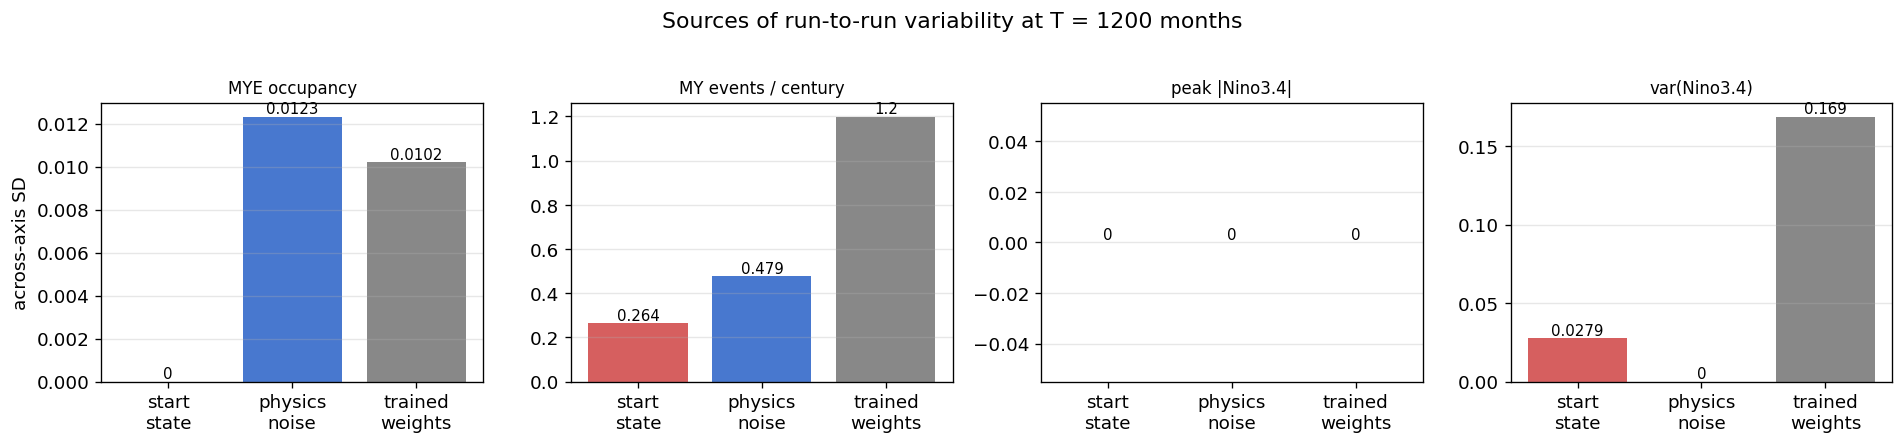

In [9]:
A, _ = GRID[T_MAIN]
fig, axes = plt.subplots(1, len(MET), figsize=(4.0 * len(MET), 3.6))
for m, (ax, name) in enumerate(zip(axes, MET)):
    d = decompose(A[:, :, m])
    vals = [d["sd_init"], d["sd_phys"], model_sd[name]]
    ax.bar(["start\nstate", "physics\nnoise", "trained\nweights"], vals,
           color=["#D65F5F", "#4878CF", "#888888"])
    ax.set_title(name, fontsize=10); ax.grid(axis="y", alpha=0.3)
    ax.set_ylabel("across-axis SD" if m == 0 else "")
    for x, v in enumerate(vals):
        ax.text(x, v, f"{v:.3g}", ha="center", va="bottom", fontsize=9)
fig.suptitle(f"Sources of run-to-run variability at T = {T_MAIN} months", y=1.02)
fig.tight_layout(); plt.show()

## Findings

*(numbers filled in from a full run of this notebook — re-run to regenerate)*